# Calibración del Autómata Celular con Caso de Estudio Histórico

<a href="https://colab.research.google.com/github/anthony-yt/wildfire-cellular-automata/blob/main/notebooks/calibracion_caso_estudio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Este notebook integra las dos fuentes de datos de la **Etapa 1 (Cimientos y Datos)** para preparar la calibración del autómata celular frente a un caso de estudio real en la Amazonía peruana (Madre de Dios / Ucayali):

1. **NASA FIRMS (Fire Information for Resource Management System):** Consulta y mapeo geoespacial con gradientes de intensidad (*Fire Radiative Power* y temperatura de brillo) de focos de calor satelitales (VIIRS 375m / MODIS).
2. **Open-Meteo ERA5 Reanalysis / OpenWeatherMap:** Serie horaria continua de velocidad, ráfagas y dirección del viento acoplada al vector de propagación del fuego.
3. **Autómata Celular con Viento:** Simulación paso a paso con el módulo `WindField` basado en las formulaciones físicas de Alexandridis et al., mostrando la elongación anisotrópica del frente de fuego en dirección al empuje del viento.

In [1]:
import os
import sys
from pathlib import Path

# ------------------------------------------------------------------------------
# Configuración para Google Colab o Entorno Local
# ------------------------------------------------------------------------------
if os.path.exists('src'):
    PROJECT_ROOT = Path('.').resolve()
elif os.path.exists('../src'):
    PROJECT_ROOT = Path('..').resolve()
else:
    # Si se ejecuta directamente en Google Colab sin clon previa
    if not os.path.exists('wildfire-cellular-automata'):
        !git clone https://github.com/anthony-yt/wildfire-cellular-automata.git
    %cd wildfire-cellular-automata
    PROJECT_ROOT = Path('.').resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from src.data.firms_client import FIRMSClient
from src.data.weather_client import WeatherClient
from src.model.grid import Grid, SANA, QUEMANDOSE, QUEMADA
from src.model.wind_influence import WindField

print(f"[*] Entorno configurado correctamente.")
print(f"[*] Raíz del proyecto: {PROJECT_ROOT}")

[*] Entorno configurado correctamente.
[*] Raíz del proyecto: C:\Users\bryan\Desktop\UNMSM\CICLO 2026 - 2\Modelos y Simulación\Proyecto\wildfire-cellular-automata


## 1. Detección y Gradientes de Focos de Calor Satelitales (NASA FIRMS)

Consultamos la API REST de NASA FIRMS para obtener las detecciones del sensor **VIIRS 375m (Suomi-NPP)** en el cuadrante de Madre de Dios (zona de Puerto Maldonado: `lat ~ -12.59°, lon ~ -69.19°`).

Los focos de calor contienen dos métricas físicas clave para modelar la intensidad del fuego:
- **Brightness (Temperatura de brillo en Kelvin):** Canal térmico que indica la temperatura radiada del píxel.
- **FRP (Fire Radiative Power en MW):** Tasa instantánea de energía liberada por la combustión. Puntos con alto FRP corresponden a frentes activos de alta severidad.

In [2]:
firms = FIRMSClient()
# Bounding Box representativo de Madre de Dios (min_lon, min_lat, max_lon, max_lat)
bbox_mdd = (-71.0, -13.5, -68.5, -11.5)

fire_points = firms.get_fire_points(
    bbox=bbox_mdd,
    day_range=1,
    source="VIIRS_SNPP_NRT",
)

lats = [p["latitude"] for p in fire_points]
lons = [p["longitude"] for p in fire_points]
frps = [p["frp"] if p["frp"] is not None else 0.5 for p in fire_points]
brights = [p["brightness"] if p["brightness"] is not None else 300.0 for p in fire_points]

print(f"[*] Consultando NASA FIRMS (VIIRS_SNPP_NRT) en Bounding Box {bbox_mdd}...")
print(f"[OK] Total de focos de calor detectados: {len(fire_points)}")
print(f"[*] Rango de FRP (Fire Radiative Power): {min(frps):.2f} MW a {max(frps):.2f} MW (Promedio: {np.mean(frps):.2f} MW)")
print(f"[*] Rango de Temperatura de Brillo: {min(brights):.1f} K a {max(brights):.1f} K (Promedio: {np.mean(brights):.1f} K)")
print()
print("Muestra de las primeras 5 detecciones:")
print("-" * 100)
print(f"{'Latitud':>10} | {'Longitud':>10} | {'Fecha/Hora':>15} | {'Satélite':>8} | {'Confianza':>9} | {'FRP (MW)':>8} | {'Brillo (K)':>10}")
print("-" * 100)
for p in fire_points[:5]:
    print(f"{p['latitude']:10.4f} | {p['longitude']:10.4f} | {p['acq_date']} {p['acq_time']:>4} | {p['satellite']:>8} | {p['confidence']:>9} | {p['frp'] or 0.0:8.2f} | {p['brightness'] or 0.0:10.1f}")
print("-" * 100)

[*] Consultando NASA FIRMS (VIIRS_SNPP_NRT) en Bounding Box (-71.0, -13.5, -68.5, -11.5)...
[OK] Total de focos de calor detectados: 155
[*] Rango de FRP (Fire Radiative Power): 0.41 MW a 79.21 MW (Promedio: 11.44 MW)
[*] Rango de Temperatura de Brillo: 291.1 K a 356.4 K (Promedio: 334.3 K)

Muestra de las primeras 5 detecciones:
----------------------------------------------------------------------------------------------------
   Latitud |   Longitud |      Fecha/Hora | Satélite | Confianza | FRP (MW) | Brillo (K)
----------------------------------------------------------------------------------------------------
  -12.8733 |   -69.7957 | 2026-09-20  601 |        N |         n |     1.06 |      312.9
  -12.7715 |   -69.8428 | 2026-09-20  601 |        N |         n |     0.93 |      310.1
  -12.7681 |   -69.8422 | 2026-09-20  601 |        N |         n |     2.07 |      335.4
  -12.7647 |   -69.8416 | 2026-09-20  601 |        N |         n |     2.07 |      305.7
  -12.7647 |   -69.84

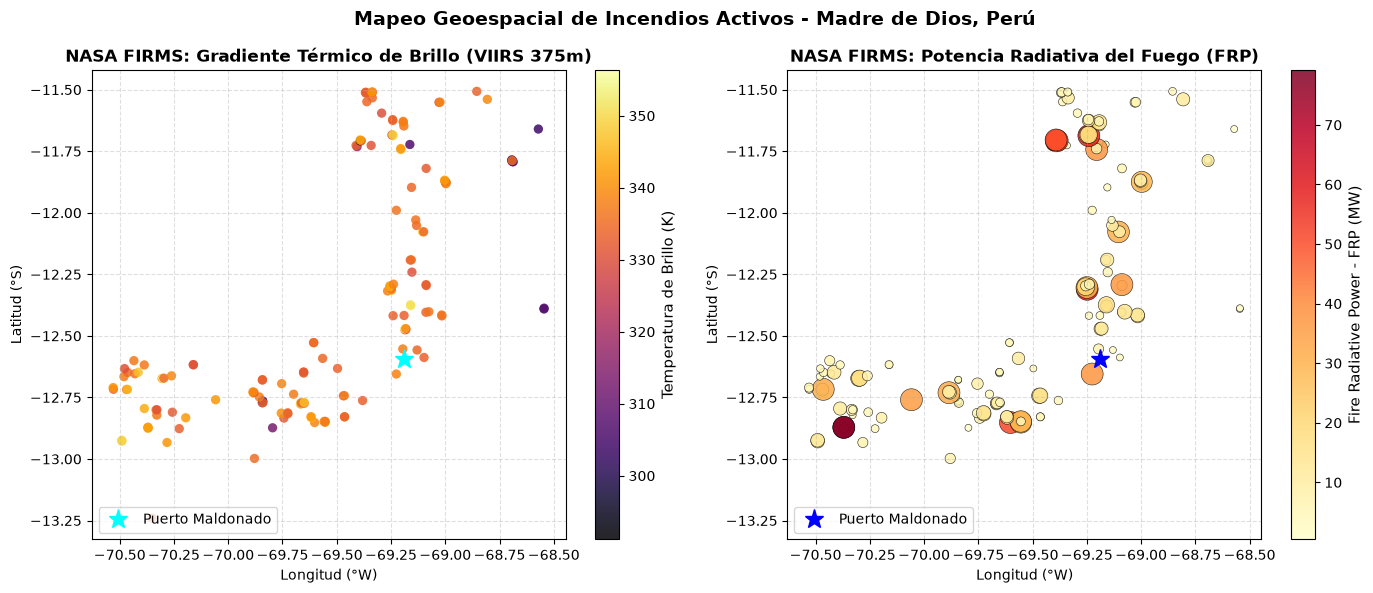

In [3]:
# Visualización de Focos de Calor con Gradientes Térmicos y de Potencia Radiativa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Gradiente de Temperatura de Brillo (Kelvin)
sc1 = ax1.scatter(lons, lats, c=brights, cmap="inferno", s=45, alpha=0.85, edgecolors="none")
cbar1 = plt.colorbar(sc1, ax=ax1)
cbar1.set_label("Temperatura de Brillo (K)", fontsize=11)
ax1.set_title("NASA FIRMS: Gradiente Térmico de Brillo (VIIRS 375m)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Longitud (°W)", fontsize=10)
ax1.set_ylabel("Latitud (°S)", fontsize=10)
ax1.grid(True, linestyle="--", alpha=0.4)
ax1.plot(-69.1891, -12.5933, marker="*", color="cyan", markersize=14, label="Puerto Maldonado", linestyle="None")
ax1.legend(loc="lower left", frameon=True)

# Panel 2: Gradiente de Potencia Radiativa FRP (MW)
sizes = np.clip(np.array(frps) * 8, 25, 250)
sc2 = ax2.scatter(lons, lats, c=frps, cmap="YlOrRd", s=sizes, alpha=0.85, edgecolors="black", linewidths=0.4)
cbar2 = plt.colorbar(sc2, ax=ax2)
cbar2.set_label("Fire Radiative Power - FRP (MW)", fontsize=11)
ax2.set_title("NASA FIRMS: Potencia Radiativa del Fuego (FRP)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Longitud (°W)", fontsize=10)
ax2.set_ylabel("Latitud (°S)", fontsize=10)
ax2.grid(True, linestyle="--", alpha=0.4)
ax2.plot(-69.1891, -12.5933, marker="*", color="blue", markersize=14, label="Puerto Maldonado", linestyle="None")
ax2.legend(loc="lower left", frameon=True)

plt.suptitle("Mapeo Geoespacial de Incendios Activos - Madre de Dios, Perú", fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

## 2. Extracción y Análisis del Viento Histórico Horario (ERA5 / Open-Meteo)

El avance de un incendio forestal es modulado drásticamente por la velocidad y dirección del viento.

> [!IMPORTANT]
> **Alineación Vectorial del Viento con la Propagación del Fuego:**
> En meteorología, `wind_deg` es la dirección **de donde procede el viento** (ej. viento del Sur = 180°).
> El fuego es empujado **hacia la dirección contraria** (hacia el Norte = 0°):
> $$\theta_{\text{fuego}} = (\theta_{\text{viento}} + 180^\circ) \pmod{360^\circ}$$
>
> El cliente `weather_client.py` calcula automáticamente este vector de propagación ($u_{\text{Este}}, v_{\text{Norte}}$) para alimentar el autómata celular.

In [4]:
weather_client = WeatherClient()
lat, lon = -12.5933, -69.1891
start_date, end_date = "2024-08-14", "2024-08-16"

serie_viento = weather_client.get_hourly_wind_series(
    lat=lat,
    lon=lon,
    start_date=start_date,
    end_date=end_date,
)

speeds = [h["speed_ms"] for h in serie_viento["series"]]
gusts = [h["gust_ms"] if h["gust_ms"] is not None else h["speed_ms"] * 1.4 for h in serie_viento["series"]]
degs = [h["deg"] for h in serie_viento["series"]]
travel_degs = [h["propagation_vector"]["travel_deg"] for h in serie_viento["series"]]
times = [h["time_utc"] for h in serie_viento["series"]]
temps = [h["temp_c"] for h in serie_viento["series"]]
humidities = [h["humidity_pct"] for h in serie_viento["series"]]

print(f"[OK] Serie horaria histórica obtenida exitosamente.")
print(f"[*] Coordenadas: Lat {lat}, Lon {lon} (Puerto Maldonado, Madre de Dios)")
print(f"[*] Rango temporal: {start_date} al {end_date} | Horas totales: {serie_viento['total_hours']}")
print(f"[*] Fuente: {serie_viento['source']}")
print(f"[*] Velocidad de viento promedio: {np.mean(speeds):.2f} m/s ({np.mean(speeds)*3.6:.2f} km/h) | Máxima: {max(speeds):.2f} m/s | Ráfaga máxima: {max(gusts):.2f} m/s")
print()
print("Primeras 5 horas registradas:")
print("-" * 100)
print(f"{'Fecha/Hora (UTC)':>16} | {'Viento (m/s)':>12} | {'Dirección':>10} | {'Cardinal':>8} | {'Empuje Fuego':>12} | {'Temp (°C)':>9} | {'Humedad (%)':>11}")
print("-" * 100)
for h in serie_viento["series"][:5]:
    print(f"{h['time_utc']:>16} | {h['speed_ms']:12.2f} | {h['deg']:9.1f}° | {h['cardinal']:>8} | {h['propagation_vector']['travel_deg']:11.1f}° | {h['temp_c']:9.1f} | {h['humidity_pct']:11.1f}")
print("-" * 100)

[OK] Serie horaria histórica obtenida exitosamente.
[*] Coordenadas: Lat -12.5933, Lon -69.1891 (Puerto Maldonado, Madre de Dios)
[*] Rango temporal: 2024-08-14 al 2024-08-16 | Horas totales: 72
[*] Fuente: Open-Meteo_ERA5_Archive_Hourly
[*] Velocidad de viento promedio: 1.54 m/s (5.53 km/h) | Máxima: 2.94 m/s | Ráfaga máxima: 6.81 m/s

Primeras 5 horas registradas:
----------------------------------------------------------------------------------------------------
Fecha/Hora (UTC) | Viento (m/s) |  Dirección | Cardinal | Empuje Fuego | Temp (°C) | Humedad (%)
----------------------------------------------------------------------------------------------------
2024-08-14T00:00 |         1.36 |     216.0° |       SW |        36.0° |      20.4 |        83.0
2024-08-14T01:00 |         0.78 |     130.0° |       SE |       310.0° |      20.1 |        85.0
2024-08-14T02:00 |         1.19 |     156.0° |      SSE |       336.0° |      19.6 |        85.0
2024-08-14T03:00 |         1.61 |     187

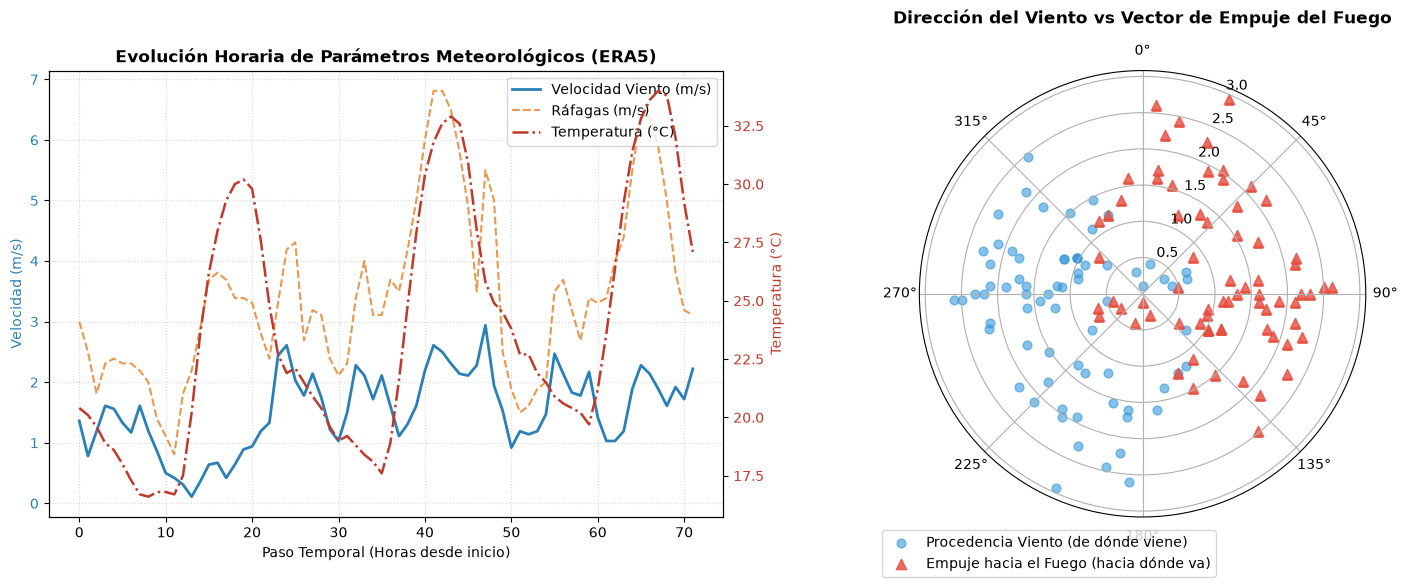

In [5]:
# Visualización de la Serie Temporal y Rosa Polar del Viento
fig = plt.figure(figsize=(15, 6))

# Panel 1: Serie Temporal de Velocidad, Ráfagas y Temperatura
ax_ts = fig.add_subplot(1, 2, 1)
x_indices = np.arange(len(times))
ax_ts.plot(x_indices, speeds, label="Velocidad Viento (m/s)", color="#2980b9", linewidth=2)
ax_ts.plot(x_indices, gusts, label="Ráfagas (m/s)", color="#e67e22", linestyle="--", linewidth=1.5, alpha=0.8)
ax_ts.set_xlabel("Paso Temporal (Horas desde inicio)", fontsize=10)
ax_ts.set_ylabel("Velocidad (m/s)", fontsize=10, color="#2980b9")
ax_ts.tick_params(axis="y", labelcolor="#2980b9")
ax_ts.grid(True, linestyle=":", alpha=0.5)

# Eje secundario para Temperatura
ax_temp = ax_ts.twinx()
ax_temp.plot(x_indices, temps, label="Temperatura (°C)", color="#c0392b", linewidth=1.8, linestyle="-.")
ax_temp.set_ylabel("Temperatura (°C)", fontsize=10, color="#c0392b")
ax_temp.tick_params(axis="y", labelcolor="#c0392b")

ax_ts.set_title("Evolución Horaria de Parámetros Meteorológicos (ERA5)", fontsize=12, fontweight="bold")
lines_1, labels_1 = ax_ts.get_legend_handles_labels()
lines_2, labels_2 = ax_temp.get_legend_handles_labels()
ax_ts.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

# Panel 2: Diagrama Polar de Dirección del Viento vs Empuje del Fuego
ax_polar = fig.add_subplot(1, 2, 2, projection="polar")
ax_polar.set_theta_zero_location("N")
ax_polar.set_theta_direction(-1)

wind_rads = np.radians(degs)
fire_rads = np.radians(travel_degs)

ax_polar.scatter(wind_rads, speeds, color="#3498db", alpha=0.6, s=40, label="Procedencia Viento (de dónde viene)")
ax_polar.scatter(fire_rads, speeds, color="#e74c3c", alpha=0.8, s=55, marker="^", label="Empuje hacia el Fuego (hacia dónde va)")
ax_polar.set_title("Dirección del Viento vs Vector de Empuje del Fuego", fontsize=12, fontweight="bold", pad=15)
ax_polar.legend(loc="lower left", bbox_to_anchor=(-0.1, -0.15), frameon=True)

plt.tight_layout()
plt.show()

## 3. Acoplamiento del Viento con el Autómata Celular y Simulación Espaciotemporal

Instanciamos una grilla de simulación de 50x50 celdas, iniciamos un foco de ignición central y avanzamos paso a paso alimentando las condiciones reales de viento de cada hora a través de la clase `WindField`.

La formulación de Alexandridis et al. (2008) calcula el factor multiplicador $f_w$ para cada celda vecina en la vecindad de Moore:
$$f_w = \exp\Big(c_1 \cdot V + c_2 \cdot (\cos(\theta_{\text{vecino}} - \theta_{\text{avance}}) - 1)\Big)$$

Esto provoca que el frente de fuego adquiera una **forma elíptica elongada** hacia la dirección a donde viaja el viento.

In [6]:
grid = Grid(tamano=50, prob_ignicion_base=0.35, pasos_para_quemarse=3, semilla=42)
centro = grid.tamano // 2
grid.encender_celda(centro, centro)

viento_field = WindField()

horas_simuladas = 12
pasos_a_graficar = [0, 3, 6, 9, 12]
grids_guardados = {0: grid.estado.copy()}
vientos_guardados = {0: {"speed_ms": serie_viento["series"][0]["speed_ms"], "deg": serie_viento["series"][0]["deg"], "travel_deg": serie_viento["series"][0]["propagation_vector"]["travel_deg"]}}

print("Simulación paso a paso del Autómata Celular modulado por Viento Horario Real:")
print("-" * 100)
print(f"{'Hora':>5} | {'Fecha/Hora UTC':>16} | {'Viento (m/s)':>12} | {'Dirección':>10} | {'Empuje Fuego':>12} | {'Quemándose':>11} | {'Quemadas':>9}")
print("-" * 100)

for i, hora in enumerate(serie_viento["series"][:horas_simuladas]):
    paso = i + 1
    viento_field.update_wind(speed_ms=hora["speed_ms"], wind_deg=hora["deg"])
    grid.paso_tiempo(campo_viento=viento_field)
    
    estados = grid.contar_estados()
    print(f"{paso:5d} | {hora['time_utc']:>16} | {hora['speed_ms']:12.2f} | {hora['deg']:9.1f}° | {hora['propagation_vector']['travel_deg']:11.1f}° | {estados['Quemandose']:11d} | {estados['Quemada']:9d}")
    
    if paso in pasos_a_graficar:
        grids_guardados[paso] = grid.estado.copy()
        vientos_guardados[paso] = {
            "speed_ms": hora["speed_ms"],
            "deg": hora["deg"],
            "travel_deg": hora["propagation_vector"]["travel_deg"],
        }

print("-" * 100)

Simulación paso a paso del Autómata Celular modulado por Viento Horario Real:
----------------------------------------------------------------------------------------------------
 Hora |   Fecha/Hora UTC | Viento (m/s) |  Dirección | Empuje Fuego |  Quemándose |  Quemadas
----------------------------------------------------------------------------------------------------
    1 | 2024-08-14T00:00 |         1.36 |     216.0° |        36.0° |           4 |         0
    2 | 2024-08-14T01:00 |         0.78 |     130.0° |       310.0° |          11 |         0
    3 | 2024-08-14T02:00 |         1.19 |     156.0° |       336.0° |          16 |         1
    4 | 2024-08-14T03:00 |         1.61 |     187.0° |         7.0° |          19 |         4
    5 | 2024-08-14T04:00 |         1.56 |     195.0° |        15.0° |          25 |        11
    6 | 2024-08-14T05:00 |         1.33 |     167.0° |       347.0° |          30 |        17
    7 | 2024-08-14T06:00 |         1.17 |     149.0° |       3

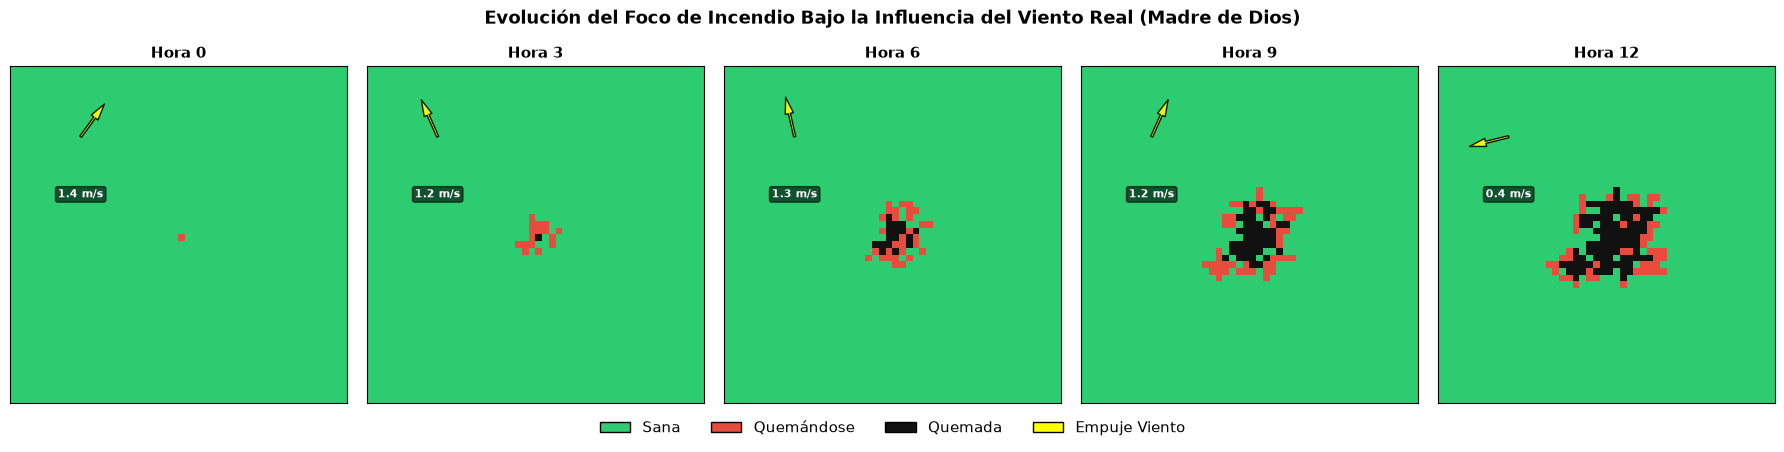

In [7]:
# Visualización de la Evolución de la Grilla en Múltiples Pasos Temporales
fig, axes = plt.subplots(1, len(pasos_a_graficar), figsize=(18, 4))
cmap_modelo = ListedColormap(["#2ecc71", "#e74c3c", "#111111", "#95a5a6"])

for idx, p in enumerate(pasos_a_graficar):
    ax = axes[idx]
    mat = grids_guardados[p]
    im = ax.imshow(mat, cmap=cmap_modelo, vmin=0, vmax=3, interpolation="nearest")
    
    # Flecha del vector de propagación del viento
    vw = vientos_guardados[p]
    sp = vw["speed_ms"]
    travel_rad = np.radians(vw["travel_deg"])
    dx = np.sin(travel_rad) * 6
    dy = -np.cos(travel_rad) * 6
    
    ax.annotate(
        "",
        xy=(10 + dx, 10 + dy),
        xytext=(10, 10),
        arrowprops=dict(facecolor="yellow", edgecolor="black", width=1.5, headwidth=6, alpha=0.9),
    )
    ax.text(10, 19, f"{sp:.1f} m/s", color="white", fontsize=8, fontweight="bold", ha="center", bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.6))
    
    ax.set_title(f"Hora {p}", fontsize=11, fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])

from matplotlib.patches import Patch
leyenda_elementos = [
    Patch(facecolor="#2ecc71", edgecolor="black", label="Sana"),
    Patch(facecolor="#e74c3c", edgecolor="black", label="Quemándose"),
    Patch(facecolor="#111111", edgecolor="black", label="Quemada"),
    Patch(facecolor="yellow", edgecolor="black", label="Empuje Viento"),
]
fig.legend(handles=leyenda_elementos, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.08), frameon=False, fontsize=11)
plt.suptitle("Evolución del Foco de Incendio Bajo la Influencia del Viento Real (Madre de Dios)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 4. Conclusiones de la Integración y Próximos Pasos (Sprint 2)

1. **Integración Completa de Fuentes:**
   - **NASA FIRMS:** Suministra focos satelitales con atributos físicos cuantitativos (FRP y Brillo) que sirven como condiciones iniciales de ignición y validación de severidad.
   - **ERA5 / Open-Meteo:** Provee series horarias continuas de viento y atmósfera de forma 100% gratuita y sin límites de cuota para calibración histórica.
2. **Comportamiento Físico del Modelo:**
   - La modulación anisotrópica de Alexandridis et al. reproduce satisfactoriamente la propagación elíptica del frente de fuego en la dirección hacia donde empuja el viento.
3. **Transición hacia el Sprint 2:**
   - Reemplazar la grilla sintética por las capas raster reales de **cobertura vegetal (ESA WorldCover 10m)** y **elevación/pendiente (SRTM 30m)** desarrolladas en la rama `Geoespacial`.